# DSC 200: Lecture 11

## Pandas cont.: Data Wrangling


## Working with the index

So far, we haven't really worked with the index because it's just been a row number; however, we can change the values we have in the index to access additional features of the pandas library.

In [32]:
import pandas as pd

taxis = pd.read_csv('../data/taxis_clean.csv', parse_dates=['pickup', 'dropoff'])
taxis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   vendorid               10000 non-null  int64         
 1   pickup                 10000 non-null  datetime64[ns]
 2   dropoff                10000 non-null  datetime64[ns]
 3   passenger_count        10000 non-null  int64         
 4   trip_distance          10000 non-null  float64       
 5   ratecodeid             10000 non-null  int64         
 6   store_and_fwd_flag     10000 non-null  object        
 7   pulocationid           10000 non-null  int64         
 8   dolocationid           10000 non-null  int64         
 9   payment_type           10000 non-null  int64         
 10  fare_amount            10000 non-null  float64       
 11  extra                  10000 non-null  float64       
 12  mta_tax                10000 non-null  float64       
 13  ti

### Setting and sorting the index

Currently, we have a RangeIndex, but we can switch to a DatetimeIndex by specifying a datetime column when calling `set_index()`:

In [33]:
taxis = taxis.set_index('pickup')
taxis.head(3)

,vendorid,dropoff,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
pickup,,,,,,,,,,,,,,,,,
2019-10-23 16:39:42,2,2019-10-23 17:14:10,1,7.93,1,N,138,170,1,29.5,1.0,0.5,7.98,6.12,0.3,47.9,2.5
2019-10-23 16:32:08,1,2019-10-23 16:45:26,1,2.00,1,N,11,26,1,10.5,1.0,0.5,0.00,0.00,0.3,12.3,0.0
2019-10-23 16:08:44,2,2019-10-23 16:21:11,1,1.36,1,N,163,162,1,9.5,1.0,0.5,2.00,0.00,0.3,15.8,2.5


Since we have a sample of the full dataset, let's sort the index to order by pickup time:

In [34]:
taxis = taxis.sort_index()

*Tip: `taxis.sort_index(axis=1)` will sort the columns by name. The `axis` parameter is present throughout the pandas library: `axis=0` targets rows and `axis=1` targets columns.*

We can now select ranges from our data based on the datetime the same way we did with row numbers:

In [35]:
taxis['2019-10-23 07:45':'2019-10-23 08']

,vendorid,dropoff,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
pickup,,,,,,,,,,,,,,,,,
2019-10-23 07:48:58,2,2019-10-23 07:52:09,1,0.67,1,N,263,141,2,4.5,1.0,0.5,0.0,0.0,0.3,8.8,2.5
2019-10-23 08:02:09,2,2019-10-24 07:42:32,1,8.38,1,N,237,33,1,32.0,1.0,0.5,5.5,0.0,0.3,41.8,2.5
2019-10-23 08:18:47,2,2019-10-23 08:36:05,1,2.39,1,N,164,237,2,12.5,1.0,0.5,0.0,0.0,0.3,16.8,2.5


When not specifying a range, we use `loc[]`:

In [36]:
taxis.loc['2019-10-23 08']

,vendorid,dropoff,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
pickup,,,,,,,,,,,,,,,,,
2019-10-23 08:02:09,2,2019-10-24 07:42:32,1,8.38,1,N,237,33,1,32.0,1.0,0.5,5.5,0.0,0.3,41.8,2.5
2019-10-23 08:18:47,2,2019-10-23 08:36:05,1,2.39,1,N,164,237,2,12.5,1.0,0.5,0.0,0.0,0.3,16.8,2.5


### Resetting the index

We will be working with time series later this section, but sometimes we want to reset our index to row numbers and restore the columns. We can make `pickup` a column again with the `reset_index()` method:

In [37]:
taxis = taxis.reset_index()
taxis.head()

,pickup,vendorid,dropoff,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2019-10-23 07:05:34,2,2019-10-23 08:03:16,3,14.68,1,N,132,181,1,50.0,1.0,0.5,4.0,0.0,0.3,55.8,0.0
1,2019-10-23 07:48:58,2,2019-10-23 07:52:09,1,0.67,1,N,263,141,2,4.5,1.0,0.5,0.0,0.0,0.3,8.8,2.5
2,2019-10-23 08:02:09,2,2019-10-24 07:42:32,1,8.38,1,N,237,33,1,32.0,1.0,0.5,5.5,0.0,0.3,41.8,2.5
3,2019-10-23 08:18:47,2,2019-10-23 08:36:05,1,2.39,1,N,164,237,2,12.5,1.0,0.5,0.0,0.0,0.3,16.8,2.5
4,2019-10-23 09:27:16,2,2019-10-23 09:33:13,2,1.11,1,N,151,41,2,6.0,1.0,0.5,0.0,0.0,0.3,7.8,0.0


## Reshaping data

The taxi dataset we have be working with is in a format conducive to an analysis. This isn't always the case. Let's now take a look at the TSA traveler throughput data, which compares 2021 throughput to the same day in 2020 and 2019:

In [38]:
tsa = pd.read_csv('../data/tsa_passenger_throughput.csv', parse_dates=['Date'])
tsa.head()

,Date,2021 Traveler Throughput,2020 Traveler Throughput,2019 Traveler Throughput
0,2021-05-14,1716561.0,250467,2664549
1,2021-05-13,1743515.0,234928,2611324
2,2021-05-12,1424664.0,176667,2343675
3,2021-05-11,1315493.0,163205,2191387
4,2021-05-10,1657722.0,215645,2512315


*Source: [TSA.gov](https://www.tsa.gov/coronavirus/passenger-throughput)*

First, we will lowercase the column names and take the first word (e.g., `2021` for `2021 Traveler Throughput`) to make this easier to work with:

In [47]:
tsa = tsa.rename(columns=lambda x: x.lower().split()[0])
tsa.head()

,date,2021,2020,2019
0,2021-05-14,1716561.0,250467,2664549
1,2021-05-13,1743515.0,234928,2611324
2,2021-05-12,1424664.0,176667,2343675
3,2021-05-11,1315493.0,163205,2191387
4,2021-05-10,1657722.0,215645,2512315


Now, we can work on reshaping it.

### Melting

Melting helps convert our data into long format. Now, we have all the traveler throughput numbers in a single column:

In [48]:
tsa_melted = tsa.melt(
    id_vars='date', # column that uniquely identifies a row (can be multiple)
    var_name='year', # name for the new column created by melting
    value_name='travelers' # name for new column containing values from melted columns
)
tsa_melted.sample(5, random_state=1) # show some random entries

,date,year,travelers
974,2020-09-12,2019,1879822.0
435,2021-03-05,2020,2198517.0
1029,2020-07-19,2019,2727355.0
680,2020-07-03,2020,718988.0
867,2020-12-28,2019,2500396.0


To convert this into a time series of traveler throughput, we need to replace the year in the `date` column with the one in the `year` column. Otherwise, we are marking prior years' numbers with the wrong year.

In [49]:
tsa_melted = tsa_melted.assign(
    date=lambda x: pd.to_datetime(x.year + x.date.dt.strftime('-%m-%d'))
)
tsa_melted.sample(5, random_state=1)

,date,year,travelers
974,2019-09-12,2019,1879822.0
435,2020-03-05,2020,2198517.0
1029,2019-07-19,2019,2727355.0
680,2020-07-03,2020,718988.0
867,2019-12-28,2019,2500396.0


This leaves us with some null values (the dates that aren't present in the dataset):

In [50]:
tsa_melted.sort_values('date').tail(3)

,date,year,travelers
136,2021-12-29,2021,NaN
135,2021-12-30,2021,NaN
134,2021-12-31,2021,NaN


These can be dropped with the `dropna()` method:

In [51]:
tsa_melted = tsa_melted.dropna()
tsa_melted.sort_values('date').tail(3)

,date,year,travelers
2,2021-05-12,2021,1424664.0
1,2021-05-13,2021,1743515.0
0,2021-05-14,2021,1716561.0


### Pivoting

Using the melted data, we can pivot the data to compare TSA traveler throughput on specific days across years:

In [52]:
tsa_pivoted = tsa_melted\
    .query('date.dt.month == 3 and date.dt.day <= 10')\
    .assign(day_in_march=lambda x: x.date.dt.day)\
    .pivot(index='year', columns='day_in_march', values='travelers')
tsa_pivoted

day_in_march,1,2,3,4,5,6,7,8,9,10
year,,,,,,,,,,
2019,2257920.0,1979558.0,2143619.0,2402692.0,2543689.0,2156262.0,2485430.0,2378673.0,2122898.0,2187298.0
2020,2089641.0,1736393.0,1877401.0,2130015.0,2198517.0,1844811.0,2119867.0,1909363.0,1617220.0,1702686.0
2021,1049692.0,744812.0,826924.0,1107534.0,1168734.0,992406.0,1278557.0,1119303.0,825745.0,974221.0


**Important**: We aren't covering the `unstack()` and `stack()` methods, which are additional ways to pivot and melt, respectively. These come in handy when we have a multi-level index (e.g., if we ran `set_index()` with more than one column). More information can be found [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/reshaping.html).

### Transposing

The `T` attribute provides a quick way to flip rows and columns.

In [53]:
tsa_pivoted.T

year,2019,2020,2021
day_in_march,,,
1,2257920.0,2089641.0,1049692.0
2,1979558.0,1736393.0,744812.0
3,2143619.0,1877401.0,826924.0
4,2402692.0,2130015.0,1107534.0
5,2543689.0,2198517.0,1168734.0
6,2156262.0,1844811.0,992406.0
7,2485430.0,2119867.0,1278557.0
8,2378673.0,1909363.0,1119303.0
9,2122898.0,1617220.0,825745.0


### Merging

We typically observe changes in air travel around the holidays, so adding information about the dates in the TSA dataset provides more context. The `holidays.csv` file contains a few major holidays in the United States:

In [54]:
holidays = pd.read_csv('../data/holidays.csv', parse_dates=True, index_col='date')
holidays.loc['2019']

,holiday
date,
2019-01-01,New Year's Day
2019-05-27,Memorial Day
2019-07-04,July 4th
2019-09-02,Labor Day
2019-11-28,Thanksgiving
2019-12-24,Christmas Eve
2019-12-25,Christmas Day
2019-12-31,New Year's Eve


Merging the holidays with the TSA traveler throughput data will provide more context for our analysis:

In [65]:
tsa_melted_holidays = tsa_melted\
    .merge(holidays, left_on='date', right_index=True, how='left')\
    .sort_values('date')
tsa_melted_holidays.head()
#tsa_melted_holidays[tsa_melted_holidays.date == pd.to_datetime('2019-07-04')]

,date,year,travelers,holiday
863,2019-01-01,2019,2126398.0,New Year's Day
862,2019-01-02,2019,2345103.0,NaN
861,2019-01-03,2019,2202111.0,NaN
860,2019-01-04,2019,2150571.0,NaN
859,2019-01-05,2019,1975947.0,NaN


*Tip: There are many parameters for this method, so be sure to check out the [documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html). To append rows, take a look at the `pd.concat()` function.*

We can take this a step further by marking a few days before and after each holiday as part of the holiday. This would make it easier to compare holiday travel across years and look for any uptick in travel around the holidays:

In [66]:
tsa_melted_holiday_travel = tsa_melted_holidays.assign(
    holiday=lambda x:
        x.holiday\
            .fillna(method='ffill', limit=1)\
            .fillna(method='bfill', limit=2)
)

C:\Users\jsand\AppData\Local\Temp\ipykernel_5596\1755781543.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill', limit=1)\
C:\Users\jsand\AppData\Local\Temp\ipykernel_5596\1755781543.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill', limit=2)


*Tip: Check out the [documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html) for the full list of functionality available with the `fillna()` method.*

Notice that we now have values for the day after each holiday and the two days prior. Thanksgiving in 2019 was on November 28th, so the 26th, 27th, and 29th were filled. Since we are only replacing null values, we don't override Christmas Day with the forward fill of Christmas Eve:

In [67]:
tsa_melted_holiday_travel.query(
    'year == "2019" and '
    '(holiday == "Thanksgiving" or holiday.str.contains("Christmas"))'
)

,date,year,travelers,holiday
899,2019-11-26,2019,1591158.0,Thanksgiving
898,2019-11-27,2019,1968137.0,Thanksgiving
897,2019-11-28,2019,2648268.0,Thanksgiving
896,2019-11-29,2019,2882915.0,Thanksgiving
873,2019-12-22,2019,1981433.0,Christmas Eve
872,2019-12-23,2019,1937235.0,Christmas Eve
871,2019-12-24,2019,2552194.0,Christmas Eve
870,2019-12-25,2019,2582580.0,Christmas Day
869,2019-12-26,2019,2470786.0,Christmas Day


### Exercise 3

Using the meteorite data from the `Meteorite_Landings.csv` file, create a pivot table that shows both the number of meteorites and the 95th percentile of meteorite mass for those that were found versus observed falling per year from 2005 through 2009 (inclusive). Hint: Be sure to convert the `year` column to a number as we did in the previous exercise.

### Exercise 4

Using the meteorite data from the `Meteorite_Landings.csv` file, find the median and 98th percentile for mass of the meteorites that were found versus observed falling.

Class[Buzz]: `lec11-1`

In [83]:
meteorite = pd.read_csv('../data/Meteorite_Landings.csv')
meteorite.head()

meteorite_grouped = meteorite.groupby('fall')['mass (g)'].quantile([0.5, 0.98])
meteorite_grouped

fall       
Fell   0.50      2800.0
       0.98    230000.0
Found  0.50        30.5
       0.98     13700.0
Name: mass (g), dtype: float64

## Time series

- When working with time series data, pandas provides us with additional functionality to not just compare the observations in our dataset, but to use their relationship in time to analyze the data. 
- In this section, we will see a few such operations for selecting date/time ranges, calculating changes over time, performing window calculations, and resampling the data to different date/time intervals.

### Selecting based on date and time

Let's switch back to the `taxis` dataset, which has timestamps of pickups and dropoffs. First, we will set the `dropoff` column as the index and sort the data:

In [84]:
taxis = taxis.set_index('dropoff').sort_index()

We saw earlier that we can slice on the datetimes:

In [85]:
taxis['2019-10-24 12':'2019-10-24 13']

,pickup,vendorid,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
dropoff,,,,,,,,,,,,,,,,,
2019-10-24 12:30:08,2019-10-23 13:25:42,2,4,0.76,1,N,140,263,2,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5
2019-10-24 12:42:01,2019-10-23 13:34:03,2,2,1.58,1,N,114,234,1,7.5,1.0,0.5,2.36,0.0,0.3,14.16,2.5


We can also represent this range with shorthand. Note that we must use `loc[]` here:

In [86]:
taxis.loc['2019-10-24 12']

,pickup,vendorid,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
dropoff,,,,,,,,,,,,,,,,,
2019-10-24 12:30:08,2019-10-23 13:25:42,2,4,0.76,1,N,140,263,2,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5
2019-10-24 12:42:01,2019-10-23 13:34:03,2,2,1.58,1,N,114,234,1,7.5,1.0,0.5,2.36,0.0,0.3,14.16,2.5


However, if we want to look at this time range across days, we need another strategy.

We can pull out the dropoffs that happened between a certain time range on *any* day with the `between_time()` method:

In [87]:
taxis.between_time('12:00', '13:00')

,pickup,vendorid,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
dropoff,,,,,,,,,,,,,,,,,
2019-10-23 12:53:49,2019-10-23 12:35:27,2,5,2.49,1,N,262,238,1,13.5,1.0,0.5,2.20,0.0,0.3,20.00,2.5
2019-10-24 12:30:08,2019-10-23 13:25:42,2,4,0.76,1,N,140,263,2,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5
2019-10-24 12:42:01,2019-10-23 13:34:03,2,2,1.58,1,N,114,234,1,7.5,1.0,0.5,2.36,0.0,0.3,14.16,2.5


*Tip: The `at_time()` method can be used to extract all entries at a given time (e.g., 12:35:27).*

Finally, `head()` and `tail()` limit us to a number of rows, but we may be interested in rows within the first/last 2 hours (or any other time interval) of the data, in which case, we should use `first()` / `last()`:

In [93]:
taxis.first('1h')

C:\Users\jsand\AppData\Local\Temp\ipykernel_5596\2449197755.py:1: FutureWarning: first is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  taxis.first('1h')


,pickup,vendorid,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
dropoff,,,,,,,,,,,,,,,,,
2019-10-23 07:52:09,2019-10-23 07:48:58,2,1,0.67,1,N,263,141,2,4.5,1.0,0.5,0.0,0.0,0.3,8.8,2.5
2019-10-23 08:03:16,2019-10-23 07:05:34,2,3,14.68,1,N,132,181,1,50.0,1.0,0.5,4.0,0.0,0.3,55.8,0.0
2019-10-23 08:36:05,2019-10-23 08:18:47,2,1,2.39,1,N,164,237,2,12.5,1.0,0.5,0.0,0.0,0.3,16.8,2.5


*Tip: Available date/time offsets can be found in the pandas documentation [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects).* 

For the rest of this section, we will be working with the TSA traveler throughput data. Let's start by setting the index to the `date` column:

In [89]:
tsa_melted_holiday_travel = tsa_melted_holiday_travel.set_index('date')

### Calculating change over time

In [94]:
tsa_melted_holiday_travel.loc['2020'].assign(
    one_day_change=lambda x: x.travelers.diff(),
    seven_day_change=lambda x: x.travelers.diff(7),
).head(10)

,year,travelers,holiday,one_day_change,seven_day_change
date,,,,,
2020-01-01,2020,2311732.0,New Year's Day,NaN,NaN
2020-01-02,2020,2178656.0,New Year's Day,-133076.0,NaN
2020-01-03,2020,2422272.0,NaN,243616.0,NaN
2020-01-04,2020,2210542.0,NaN,-211730.0,NaN
2020-01-05,2020,1806480.0,NaN,-404062.0,NaN
2020-01-06,2020,1815040.0,NaN,8560.0,NaN
2020-01-07,2020,2034472.0,NaN,219432.0,NaN
2020-01-08,2020,2072543.0,NaN,38071.0,-239189.0
2020-01-09,2020,1687974.0,NaN,-384569.0,-490682.0


*Tip: To perform operations other than subtraction, take a look at the `shift()` method. It also makes it possible to perform operations across columns.*

### Resampling
We can use resampling to aggregate time series data to a new frequency:

In [95]:
tsa_melted_holiday_travel['2019':'2021-Q1'].select_dtypes(include='number')\
    .resample('QE').agg(['sum', 'mean', 'std'])

travelers                             
                    sum          mean            std
date                                                
2019-03-31  189281658.0  2.103130e+06  282239.618354
2019-06-30  221756667.0  2.436886e+06  212600.697665
2019-09-30  220819236.0  2.400209e+06  260140.242892
2019-12-31  211103512.0  2.294603e+06  260510.040655
2020-03-31  155354148.0  1.726157e+06  685094.277420
2020-06-30   25049083.0  2.752646e+05  170127.402046
2020-09-30   63937115.0  6.949686e+05  103864.705739
2020-12-31   77541248.0  8.428397e+05  170245.484185
2021-03-31   86094635.0  9.566071e+05  280399.809061

### Window calculations

 - Window calculations are similar to group by calculations except the group over which the calculation is performed isn't static &ndash; it can move or expand. 
 - Pandas provides functionality for constructing a variety of windows, including moving/rolling windows, expanding windows (e.g., cumulative sum or mean up to the current date in a time series), and exponentially weighted moving windows (to weight closer observations more than further ones).
 - We will only look at rolling and expanding calculations here.

Performing a window calculation is very similar to a group by calculation &ndash; we first define the window, and then we specify the aggregation:

In [98]:
tsa_melted_holiday_travel.loc['2020'].assign(
    **{
        '7D MA': lambda x: x.rolling('7D').travelers.mean(),
        'YTD mean': lambda x: x.expanding().travelers.mean()
      }
).head(10)

,year,travelers,holiday,7D MA,YTD mean
date,,,,,
2020-01-01,2020,2311732.0,New Year's Day,2.311732e+06,2.311732e+06
2020-01-02,2020,2178656.0,New Year's Day,2.245194e+06,2.245194e+06
2020-01-03,2020,2422272.0,NaN,2.304220e+06,2.304220e+06
2020-01-04,2020,2210542.0,NaN,2.280800e+06,2.280800e+06
2020-01-05,2020,1806480.0,NaN,2.185936e+06,2.185936e+06
2020-01-06,2020,1815040.0,NaN,2.124120e+06,2.124120e+06
2020-01-07,2020,2034472.0,NaN,2.111313e+06,2.111313e+06
2020-01-08,2020,2072543.0,NaN,2.077144e+06,2.106467e+06
2020-01-09,2020,1687974.0,NaN,2.007046e+06,2.059968e+06


To understand what's happening, it's best to visualize the original data and the result, so here's a sneak peek of plotting with pandas.

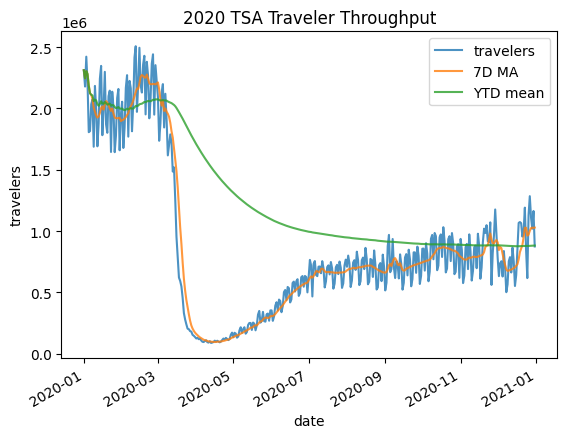

In [99]:
_ = tsa_melted_holiday_travel.loc['2020'].assign(
    **{
        '7D MA': lambda x: x.rolling('7D').travelers.mean(),
        'YTD mean': lambda x: x.expanding().travelers.mean()
      }
).plot(title='2020 TSA Traveler Throughput', ylabel='travelers', alpha=0.8)

Other types of windows:
- [exponentially weighted moving](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.ewm.html): use the `ewm()` method
- [custom](https://pandas.pydata.org/docs/user_guide/window.html#window-custom-rolling-window): create a subclass of `pandas.api.indexers.BaseIndexer` or use a pre-built one in `pandas.api.indexers`